In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

In [2]:
df=pd.read_csv("merged_CIC_IDS2017.csv")

In [3]:
df.columns=df.columns.str.strip()

In [4]:
df.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,54865,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,55054,109,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,55055,52,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,46236,34,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,54863,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [5]:
print("Dataset Shape:", df.shape)

Dataset Shape: (2830743, 79)


In [6]:
print("Columns:",df.columns)

Columns: Index(['Destination Port', 'Flow Duration', 'Total Fwd Packets',
       'Total Backward Packets', 'Total Length of Fwd Packets',
       'Total Length of Bwd Packets', 'Fwd Packet Length Max',
       'Fwd Packet Length Min', 'Fwd Packet Length Mean',
       'Fwd Packet Length Std', 'Bwd Packet Length Max',
       'Bwd Packet Length Min', 'Bwd Packet Length Mean',
       'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s',
       'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min',
       'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max',
       'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std',
       'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags',
       'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length',
       'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s',
       'Min Packet Length', 'Max Packet Length', 'Packet Length Mean',
       'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count',
       'SY

#### Columns where almost all values are zero (e.g., Fwd URG Flags, Bwd URG Flags, CWE Flag Count, ECE Flag Count, Bwd Avg Bytes/Bulk, Bwd Avg Packets/Bulk, Bwd Avg Bulk Rate, Fwd Avg Bytes/Bulk, Fwd Avg Packets/Bulk, Fwd Avg Bulk Rate) — these add noise.



In [7]:
df.describe()

c:\Users\vp532\OneDrive\Desktop\Mini_Project\.venv\Lib\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
c:\Users\vp532\OneDrive\Desktop\Mini_Project\.venv\Lib\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
count,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,...,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06
mean,8.071483e+03,1.478566e+07,9.361160e+00,1.039377e+01,5.493024e+02,1.616264e+04,2.075999e+02,1.871366e+01,5.820194e+01,6.891013e+01,...,5.418218e+00,-2.741688e+03,8.155132e+04,4.113412e+04,1.531825e+05,5.829582e+04,8.316037e+06,5.038439e+05,8.695752e+06,7.920031e+06
std,1.828363e+04,3.365374e+07,7.496728e+02,9.973883e+02,9.993589e+03,2.263088e+06,7.171848e+02,6.033935e+01,1.860912e+02,2.811871e+02,...,6.364257e+02,1.084989e+06,6.485999e+05,3.933815e+05,1.025825e+06,5.770923e+05,2.363008e+07,4.602984e+06,2.436689e+07,2.336342e+07
min,0.000000e+00,-1.300000e+01,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,-5.368707e+08,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,5.300000e+01,1.550000e+02,2.000000e+00,1.000000e+00,1.200000e+01,0.000000e+00,6.000000e+00,0.000000e+00,6.000000e+00,0.000000e+00,...,0.000000e+00,2.000000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,8.000000e+01,3.131600e+04,2.000000e+00,2.000000e+00,6.200000e+01,1.230000e+02,3.700000e+01,2.000000e+00,3.400000e+01,0.000000e+00,...,1.000000e+00,2.400000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,4.430000e+02,3.204828e+06,5.000000e+00,4.000000e+00,1.870000e+02,4.820000e+02,8.100000e+01,3.600000e+01,5.000000e+01,2.616295e+01,...,2.000000e+00,3.200000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
max,6.553500e+04,1.200000e+08,2.197590e+05,2.919220e+05,1.290000e+07,6.554530e+08,2.482000e+04,2.325000e+03,5.940857e+03,7.125597e+03,...,2.135570e+05,1.380000e+02,1.100000e+08,7.420000e+07,1.100000e+08,1.100000e+08,1.200000e+08,7.690000e+07,1.200000e+08,1.200000e+08


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2830743 entries, 0 to 2830742
Data columns (total 79 columns):
 #   Column                       Dtype  
---  ------                       -----  
 0   Destination Port             int64  
 1   Flow Duration                int64  
 2   Total Fwd Packets            int64  
 3   Total Backward Packets       int64  
 4   Total Length of Fwd Packets  int64  
 5   Total Length of Bwd Packets  int64  
 6   Fwd Packet Length Max        int64  
 7   Fwd Packet Length Min        int64  
 8   Fwd Packet Length Mean       float64
 9   Fwd Packet Length Std        float64
 10  Bwd Packet Length Max        int64  
 11  Bwd Packet Length Min        int64  
 12  Bwd Packet Length Mean       float64
 13  Bwd Packet Length Std        float64
 14  Flow Bytes/s                 float64
 15  Flow Packets/s               float64
 16  Flow IAT Mean                float64
 17  Flow IAT Std                 float64
 18  Flow IAT Max                 int64  
 19  

In [9]:
df[df.duplicated()]

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
2109,80,77,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2257,443,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2749,443,49,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2862,443,4,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2877,443,1,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2830701,53,179,2,2,46,46,23,23,23.0,0.0,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2830725,53,161,2,2,82,114,41,41,41.0,0.0,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2830726,53,212,2,2,84,162,42,42,42.0,0.0,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2830731,443,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [ ]:
# realtime_features = [
#     'Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets',
#     'Total Length of Fwd Packets', 'Total Length of Bwd Packets',
#     'Fwd Packet Length Min', 'Fwd Packet Length Max', 'Fwd Packet Length Mean', 'Fwd Packet Length Std',
#     'Bwd Packet Length Min', 'Bwd Packet Length Max', 'Bwd Packet Length Mean', 'Bwd Packet Length Std',
#     'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance',
#     'Flow Bytes/s', 'Flow Packets/s', 'Fwd Packets/s', 'Bwd Packets/s',
#     'Init_Win_bytes_forward', 'Init_Win_bytes_backward',
#     'ACK Flag Count', 'SYN Flag Count', 'RST Flag Count', 'PSH Flag Count', 'URG Flag Count', 'ECE Flag Count',
#     'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags',
#     'min_seg_size_forward', 'Avg Fwd Segment Size', 'Avg Bwd Segment Size',
#     'Subflow Fwd Packets', 'Subflow Fwd Bytes', 'Subflow Bwd Packets', 'Subflow Bwd Bytes',
#     'act_data_pkt_fwd', 'Idle Min', 'Idle Max', 'Idle Mean', 'Idle Std',
#     'Flow IAT Min', 'Flow IAT Max', 'Flow IAT Mean', 'Flow IAT Std',
#     'Fwd IAT Min', 'Fwd IAT Max', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Total',
#     'Bwd IAT Min', 'Bwd IAT Max', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Total',
#     'Down/Up Ratio', 'Label'
# ]

# df_realtime = df[realtime_features]


In [ ]:
# df_realtime.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2830743 entries, 0 to 2830742
Data columns (total 61 columns):
 #   Column                       Dtype  
---  ------                       -----  
 0   Destination Port             int64  
 1   Flow Duration                int64  
 2   Total Fwd Packets            int64  
 3   Total Backward Packets       int64  
 4   Total Length of Fwd Packets  int64  
 5   Total Length of Bwd Packets  int64  
 6   Fwd Packet Length Min        int64  
 7   Fwd Packet Length Max        int64  
 8   Fwd Packet Length Mean       float64
 9   Fwd Packet Length Std        float64
 10  Bwd Packet Length Min        int64  
 11  Bwd Packet Length Max        int64  
 12  Bwd Packet Length Mean       float64
 13  Bwd Packet Length Std        float64
 14  Packet Length Mean           float64
 15  Packet Length Std            float64
 16  Packet Length Variance       float64
 17  Flow Bytes/s                 float64
 18  Flow Packets/s               float64
 19  

In [ ]:
# df_realtime['Flow Bytes/s'].fillna(df_realtime['Flow Bytes/s'].median(), inplace=True)

C:\Users\vp532\AppData\Local\Temp\ipykernel_13424\3667333726.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_realtime['Flow Bytes/s'].fillna(df_realtime['Flow Bytes/s'].median(), inplace=True)
C:\Users\vp532\AppData\Local\Temp\ipykernel_13424\3667333726.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_realtime['Flow Bytes/s'].fill

In [ ]:
# df_realtime['Flow Bytes/s'].isnull()

0          False
1          False
2          False
3          False
4          False
           ...  
2830738    False
2830739    False
2830740    False
2830741    False
2830742    False
Name: Flow Bytes/s, Length: 2830743, dtype: bool

In [ ]:
# # Identify columns with negative values
# neg_cols = [col for col in df_realtime.select_dtypes(include=np.number) 
#             if (df_realtime[col] < 0).any()]
# print("Columns with Negative Values:", neg_cols)

# # Define columns to process
# replace_with_zero = [
#     'Init_Win_bytes_backward', 'Init_Win_bytes_forward', 
#     'min_seg_size_forward'
# ]
# replace_with_median = [
#     'Flow Bytes/s', 'Fwd IAT Min', 'Flow Packets/s', 
#     'Flow Duration', 'Flow IAT Min'
# ]

# # Replace negatives with 0 using .loc
# df_realtime.loc[:, replace_with_zero] = df_realtime[replace_with_zero].clip(lower=0)

# # Replace negatives with median using .loc
# for col in replace_with_median:
#     median_val = df_realtime[col].median()
#     df_realtime.loc[:, col] = np.where(df_realtime[col] < 0, median_val, df_realtime[col])

# # Verify results
# print("\nAfter replacement:")
# for col in replace_with_zero + replace_with_median:
#     print(f"{col}: min = {df_realtime[col].min()}")

Columns with Negative Values: ['Flow Duration', 'Flow Bytes/s', 'Flow Packets/s', 'Init_Win_bytes_forward', 'Init_Win_bytes_backward', 'min_seg_size_forward', 'Flow IAT Min', 'Flow IAT Max', 'Flow IAT Mean', 'Fwd IAT Min']

After replacement:
Init_Win_bytes_backward: min = 0
Init_Win_bytes_forward: min = 0
min_seg_size_forward: min = 0
Flow Bytes/s: min = 0.0
Fwd IAT Min: min = 0
Flow Packets/s: min = 0.016701329
Flow Duration: min = 0
Flow IAT Min: min = 0


In [ ]:
# df_realtime.replace([np.inf, -np.inf], np.nan, inplace=True)
# for col in df_realtime.columns:
#     if df_realtime[col].isnull().sum() > 0:
#         df_realtime[col].fillna(df_realtime[col].median(), inplace=True)

C:\Users\vp532\AppData\Local\Temp\ipykernel_13424\3120162341.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_realtime.replace([np.inf, -np.inf], np.nan, inplace=True)


In [10]:
df.duplicated().sum()

np.int64(308381)

In [11]:
df.drop_duplicates(inplace=True)

In [12]:
df.isnull().sum().sort_values(ascending=False)

Flow Bytes/s                   353
Flow Duration                    0
Destination Port                 0
Total Backward Packets           0
Total Length of Fwd Packets      0
                              ... 
Idle Mean                        0
Idle Std                         0
Idle Max                         0
Idle Min                         0
Label                            0
Length: 79, dtype: int64

In [13]:
df['Label'].unique()

array(['BENIGN', 'DDoS', 'PortScan', 'Bot', 'Infiltration',
       'Web Attack � Brute Force', 'Web Attack � XSS',
       'Web Attack � Sql Injection', 'FTP-Patator', 'SSH-Patator',
       'DoS slowloris', 'DoS Slowhttptest', 'DoS Hulk', 'DoS GoldenEye',
       'Heartbleed'], dtype=object)

In [14]:
df['Label'].value_counts()

Label
BENIGN                        2096484
DoS Hulk                       172849
DDoS                           128016
PortScan                        90819
DoS GoldenEye                   10286
FTP-Patator                      5933
DoS slowloris                    5385
DoS Slowhttptest                 5228
SSH-Patator                      3219
Bot                              1953
Web Attack � Brute Force         1470
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64

In [15]:
import numpy as np
import pandas as pd

#Select only numeric columns
numeric_df=df.select_dtypes(include=[np.number])

#Count total infinities
total_inf=np.isinf(numeric_df.values).sum()
print(f"Total infinity values: {total_inf}")

#Count infinities per column
inf_per_column=np.isinf(numeric_df).sum()
print(inf_per_column[inf_per_column > 0])  


Total infinity values: 2775
Flow Bytes/s      1211
Flow Packets/s    1564
dtype: int64


In [16]:
neg_cols=[col for col in df.select_dtypes(include=np.number) 
            if (df[col] < 0).any()]
print("Columns with Negative Values:", neg_cols)

Columns with Negative Values: ['Flow Duration', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Min', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Header Length.1', 'Init_Win_bytes_forward', 'Init_Win_bytes_backward', 'min_seg_size_forward']


In [17]:
df.replace([np.inf, -np.inf], np.nan, inplace=True)
for col in df.columns:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].median(), inplace=True)

C:\Users\vp532\AppData\Local\Temp\ipykernel_20836\2291363051.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
C:\Users\vp532\AppData\Local\Temp\ipykernel_20836\2291363051.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For examp

In [18]:
numeric_df=df.select_dtypes(include=[np.number])

total_inf=np.isinf(numeric_df.to_numpy()).sum()
print("Total infinity values:", total_inf)


Total infinity values: 0


In [ ]:
# df_realtime.isnull().sum().sort_values(ascending=False)


NameError: name 'df_realtime' is not defined

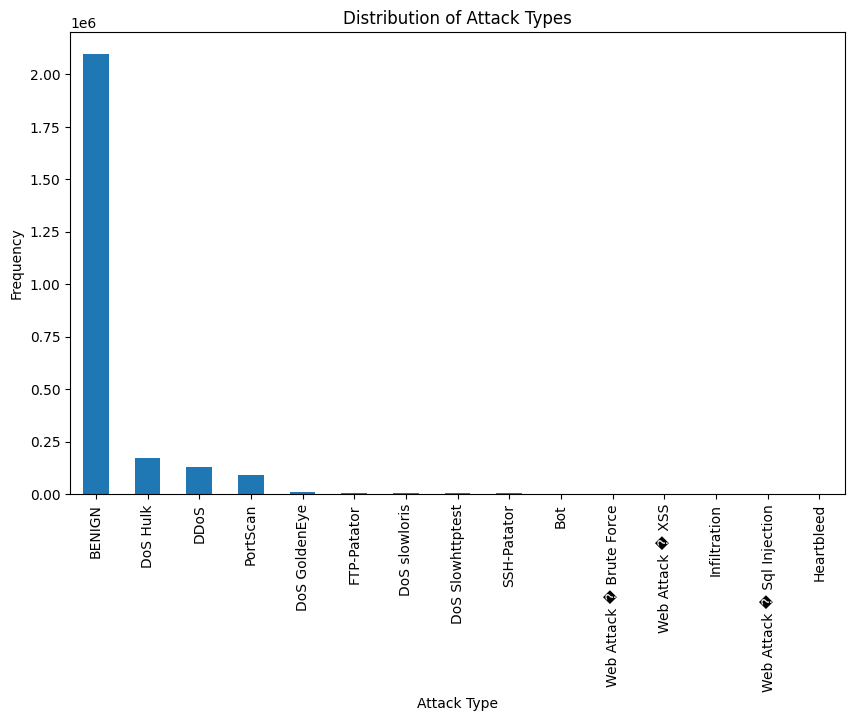

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
df['Label'].value_counts().plot(kind='bar') 
plt.title('Distribution of Attack Types')
plt.xlabel('Attack Type')
plt.ylabel('Frequency')
plt.show()


In [20]:
df['Label'] = df['Label'].apply(lambda x: 0 if x == "BENIGN" else 1)

# Check updated distribution
print(df['Label'].value_counts())

Label
0    2096484
1     425878
Name: count, dtype: int64


In [21]:
print(df['Label'].value_counts(normalize=True) * 100)


Label
0    83.115905
1    16.884095
Name: proportion, dtype: float64


In [ ]:
import numpy as np
import pandas as pd
from sklearn.feature_selection import f_classif

# X = features, y = target
X = X_train_res  # the balanced training set after SMOTE
y = y_train_res

# run ANOVA F-test
f_scores, p_values = f_classif(X, y)

# create dataframe of results
anova_results = pd.DataFrame({
    'Feature': X.columns,
    'F_score': f_scores,
    'p_value': p_values
})

# sort by F_score (descending = more discriminative)
anova_results.sort_values(by='F_score', ascending=False, inplace=True)

# display top 20 features
print(anova_results.head(20))


In [23]:
%pip install imbalanced-learn


Note: you may need to restart the kernel to use updated packages.


In [ ]:
# from sklearn.model_selection import train_test_split
# from imblearn.over_sampling import SMOTE

# X = df.drop(columns=['Label'])
# y = df['Label']

# # split
# X_train, X_test, y_train, y_test = train_test_split(
#     X, y, test_size=0.2, stratify=y, random_state=42
# )

# # apply SMOTE only on train
# smote = SMOTE(random_state=42)
# X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# print("Before SMOTE:", y_train.value_counts())
# print("After SMOTE:", y_train_res.value_counts())


Before SMOTE: Label
0    1677187
1     340702
Name: count, dtype: int64
After SMOTE: Label
0    1677187
1    1677187
Name: count, dtype: int64


In [25]:
import numpy as np
import pandas as pd
from sklearn.feature_selection import f_classif

# X = features, y = target
X = X_train_res  # the balanced training set after SMOTE
y = y_train_res

# run ANOVA F-test
f_scores, p_values = f_classif(X, y)

# create dataframe of results
anova_results = pd.DataFrame({
    'Feature': X.columns,
    'F_score': f_scores,
    'p_value': p_values
})

# sort by F_score (descending = more discriminative)
anova_results.sort_values(by='F_score', ascending=False, inplace=True)

# display top 20 features
print(anova_results.head(20))


                   Feature       F_score  p_value
12  Bwd Packet Length Mean  1.412438e+06      0.0
54    Avg Bwd Segment Size  1.412438e+06      0.0
13   Bwd Packet Length Std  1.357804e+06      0.0
10   Bwd Packet Length Max  1.352936e+06      0.0
41       Packet Length Std  1.278720e+06      0.0
39       Max Packet Length  1.223660e+06      0.0
40      Packet Length Mean  1.128379e+06      0.0
52     Average Packet Size  1.099598e+06      0.0
42  Packet Length Variance  9.208574e+05      0.0
22             Fwd IAT Std  8.713737e+05      0.0
76                Idle Max  8.187347e+05      0.0
18            Flow IAT Max  8.137652e+05      0.0
23             Fwd IAT Max  8.123521e+05      0.0
74               Idle Mean  7.869926e+05      0.0
38       Min Packet Length  7.426526e+05      0.0
11   Bwd Packet Length Min  7.329479e+05      0.0
77                Idle Min  7.248962e+05      0.0
17            Flow IAT Std  6.994045e+05      0.0
20           Fwd IAT Total  3.908483e+05      0.0


c:\Users\vp532\OneDrive\Desktop\Mini_Project\.venv\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:110: UserWarning: Features [31 33 56 57 58 59 60 61] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
c:\Users\vp532\OneDrive\Desktop\Mini_Project\.venv\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


In [ ]:
df_corr=df.corr(numeric_only=True)


feature-to-feature correlation (multicollinearity)

<Axes: >

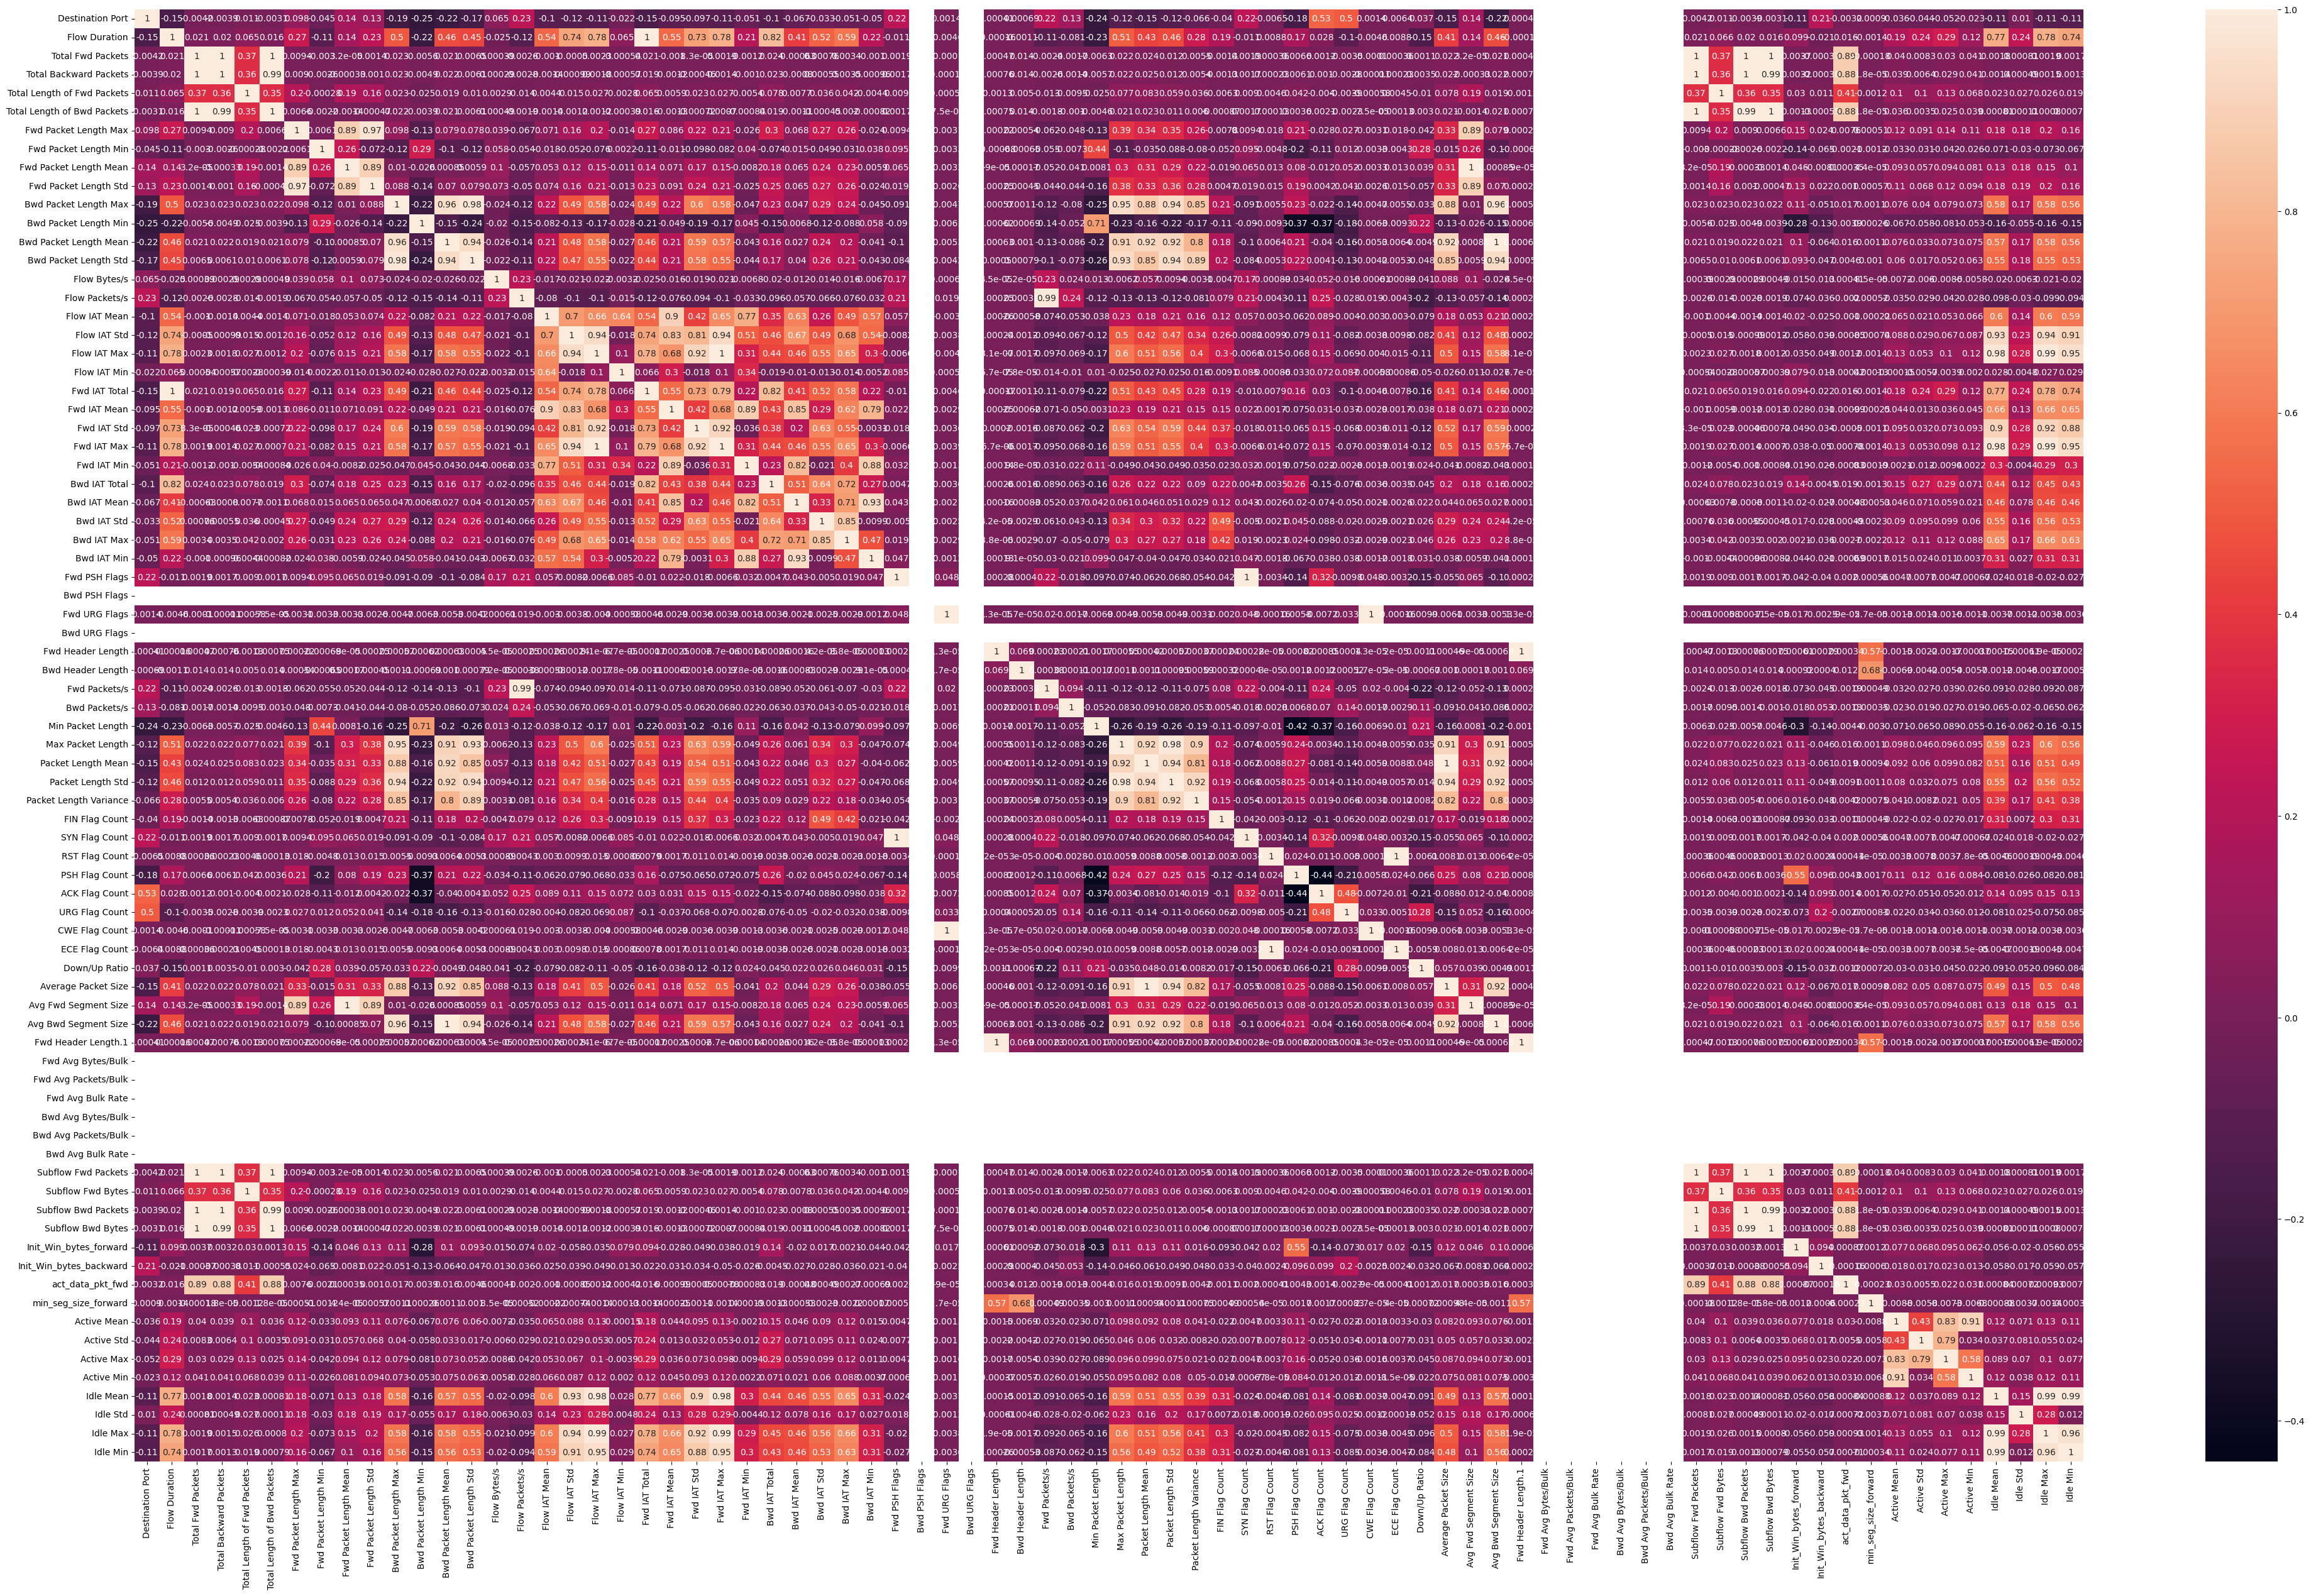

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(50,30))
sns.heatmap(df_corr,annot=True)

In [ ]:
df.corr()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
Destination Port,1.000000,-0.171828,-0.004652,-0.004356,0.009611,-0.003388,0.090989,-0.047160,0.136916,0.123060,...,0.001003,-0.040678,-0.048227,-0.058142,-0.027193,-0.127989,0.006732,-0.123677,-0.129539,-0.094910
Flow Duration,-0.171828,1.000000,0.020571,0.019389,0.063509,0.015998,0.263401,-0.115716,0.134033,0.224957,...,-0.001236,0.184985,0.238497,0.289933,0.117259,0.764124,0.240369,0.775744,0.734123,0.145470
Total Fwd Packets,-0.004652,0.020571,1.000000,0.999070,0.365510,0.996993,0.009071,-0.003255,-0.000262,0.001110,...,-0.000181,0.039822,0.008207,0.030318,0.041186,0.001402,0.000676,0.001483,0.001266,-0.002793
Total Backward Packets,-0.004356,0.019389,0.999070,1.000000,0.359457,0.994430,0.008764,-0.002834,-0.000617,0.000743,...,0.000021,0.038853,0.006318,0.028465,0.041185,0.001020,0.000364,0.001045,0.000938,-0.002709
Total Length of Fwd Packets,0.009611,0.063509,0.365510,0.359457,1.000000,0.353781,0.196242,-0.001737,0.185073,0.158876,...,-0.001193,0.100416,0.102761,0.125756,0.067749,0.020631,0.026406,0.024051,0.016646,-0.011724
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Idle Mean,-0.127989,0.764124,0.001402,0.001020,0.020631,0.000507,0.171741,-0.078508,0.119915,0.174644,...,-0.000772,0.115764,0.032325,0.083236,0.114740,1.000000,0.146772,0.990238,0.990080,0.278336
Idle Std,0.006732,0.240369,0.000676,0.000364,0.026406,0.000010,0.175465,-0.032433,0.176961,0.188847,...,-0.003688,0.069021,0.080148,0.068147,0.037001,0.146772,1.000000,0.280971,0.007133,0.042247
Idle Max,-0.123677,0.775744,0.001483,0.001045,0.024051,0.000491,0.190272,-0.080809,0.140576,0.194932,...,-0.001306,0.128352,0.051179,0.097203,0.119259,0.990238,0.280971,1.000000,0.961254,0.277214
Idle Min,-0.129539,0.734123,0.001266,0.000938,0.016646,0.000498,0.147625,-0.074259,0.096046,0.149199,...,-0.000240,0.105523,0.019362,0.071685,0.109544,0.990080,0.007133,0.961254,1.000000,0.275874
